
Sample size n=5:
  Mean of sample means: 0.4981
  Theoretical mean: 0.5000
  SD of sample means: 0.2234
  Theoretical SD: 0.2236

Sample size n=10:
  Mean of sample means: 0.5005
  Theoretical mean: 0.5000
  SD of sample means: 0.1568
  Theoretical SD: 0.1581

Sample size n=30:
  Mean of sample means: 0.5000
  Theoretical mean: 0.5000
  SD of sample means: 0.0922
  Theoretical SD: 0.0913

Sample size n=100:
  Mean of sample means: 0.5001
  Theoretical mean: 0.5000
  SD of sample means: 0.0505
  Theoretical SD: 0.0500


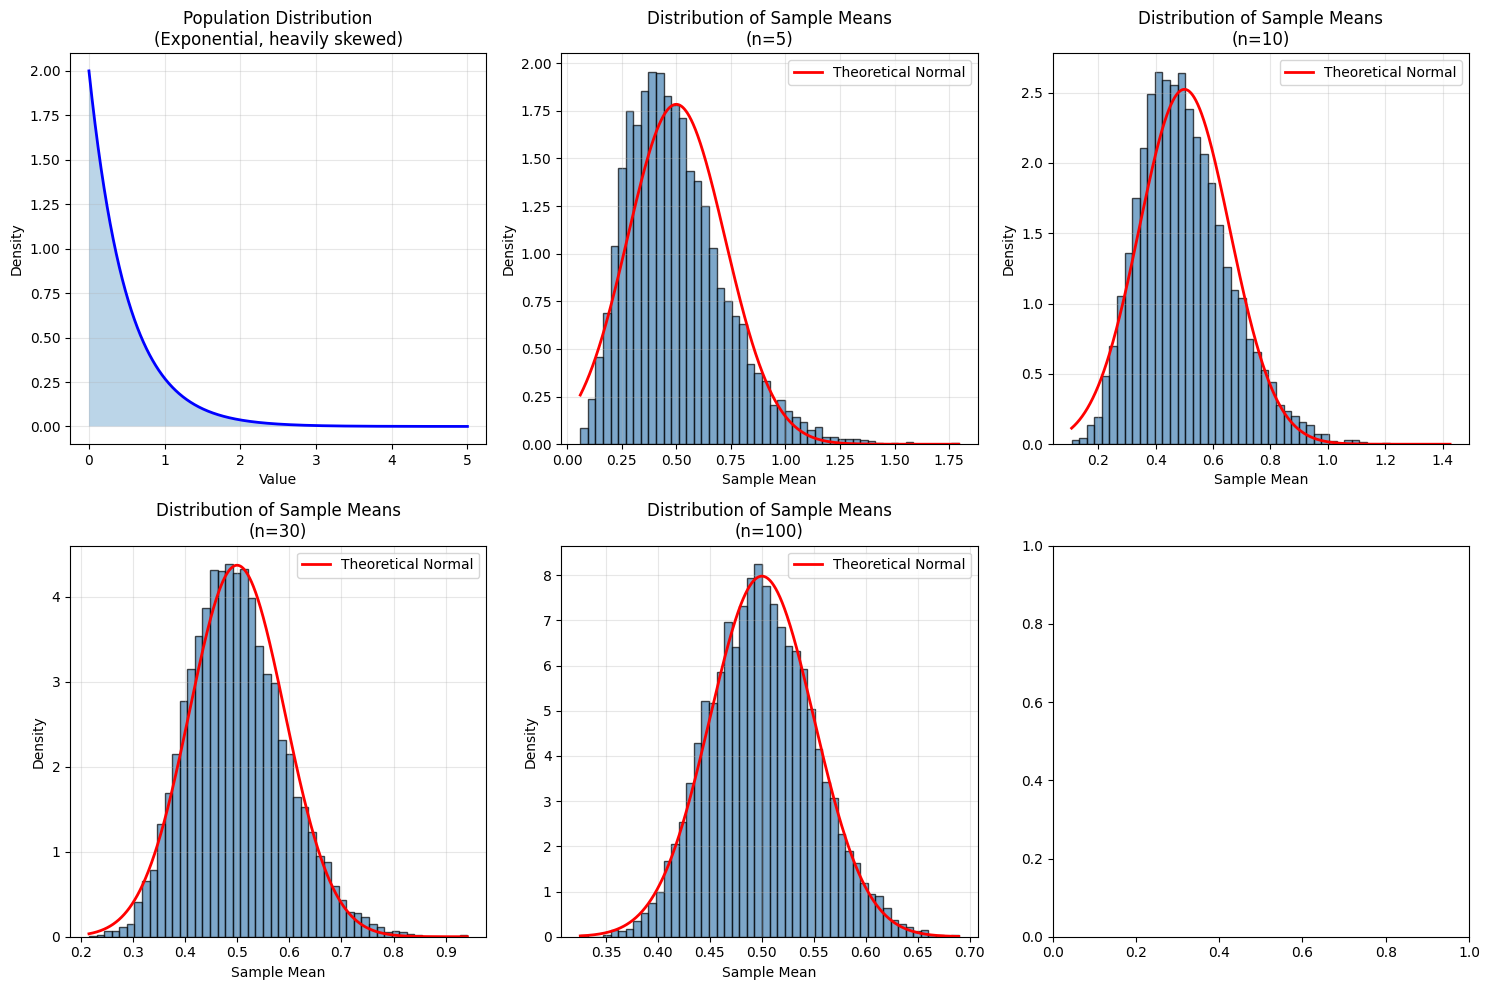


Key Observation: Even though the population is heavily skewed,
the distribution of sample means becomes increasingly normal as n increases!


In [2]:
# Start with a heavily skewed distribution (exponential)
# Show that sample means become normal
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)

# Parameters
population_lambda = 2  # rate parameter for exponential
sample_sizes = [5, 10, 30, 100]
n_samples = 10000

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot the population distribution
x_pop = np.linspace(0, 5, 1000)
y_pop = stats.expon.pdf(x_pop, scale=1/population_lambda)
axes[0].plot(x_pop, y_pop, 'b-', linewidth=2)
axes[0].fill_between(x_pop, y_pop, alpha=0.3)
axes[0].set_title('Population Distribution\n(Exponential, heavily skewed)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.3)

# For each sample size, generate sample means and plot
for idx, n in enumerate(sample_sizes, start=1):
    # Generate many samples and calculate their means
    sample_means = []
    for _ in range(n_samples):
        sample = np.random.exponential(scale=1/population_lambda, size=n)
        sample_means.append(np.mean(sample))
    
    sample_means = np.array(sample_means)
    
    # Plot histogram of sample means
    axes[idx].hist(sample_means, bins=50, density=True, 
                   alpha=0.7, color='steelblue', edgecolor='black')
    
    # Overlay theoretical normal distribution
    # Mean of sample means = population mean = 1/lambda
    # SD of sample means = population SD / sqrt(n) = (1/lambda) / sqrt(n)
    theoretical_mean = 1 / population_lambda
    theoretical_sd = (1 / population_lambda) / np.sqrt(n)
    
    x_theoretical = np.linspace(sample_means.min(), sample_means.max(), 1000)
    y_theoretical = stats.norm.pdf(x_theoretical, 
                                   loc=theoretical_mean, 
                                   scale=theoretical_sd)
    
    axes[idx].plot(x_theoretical, y_theoretical, 'r-', 
                   linewidth=2, label='Theoretical Normal')
    
    axes[idx].set_title(f'Distribution of Sample Means\n(n={n})')
    axes[idx].set_xlabel('Sample Mean')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    
    # Print summary statistics
    print(f"\nSample size n={n}:")
    print(f"  Mean of sample means: {np.mean(sample_means):.4f}")
    print(f"  Theoretical mean: {theoretical_mean:.4f}")
    print(f"  SD of sample means: {np.std(sample_means):.4f}")
    print(f"  Theoretical SD: {theoretical_sd:.4f}")

plt.tight_layout()
plt.show()

print("\nKey Observation: Even though the population is heavily skewed,")
print("the distribution of sample means becomes increasingly normal as n increases!")